In [3]:
%load_ext autoreload
%autoreload 2


from causalml.dataset import synthetic_data
import pandas as pd

n = 100000
Y, X, T, _, _, _ = synthetic_data(mode=2, n=n, p=10, sigma=3.0) # Simulate randomized trial: mode=2

df = pd.DataFrame(X)
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df.columns = feature_names
df['outcome'] = Y
df['treatment'] = T
df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment
0,-1.078263,-2.019341,0.633393,-1.375948,0.911162,-0.006593,-0.605594,0.406250,-0.534275,1.415750,4.033153,1
1,-0.517569,2.995388,1.388610,-0.598988,0.744653,0.751369,-0.679290,1.674606,-1.185082,0.671905,-1.542053,0
2,1.126988,-2.001372,-0.448612,0.631098,0.310586,-0.166734,-0.118702,-0.616534,1.743450,1.737600,-6.289168,0
3,0.053044,-0.672439,1.038246,-1.612507,-1.452984,0.652280,-0.209767,0.176709,-0.657934,-0.910686,1.406100,1
4,-0.237088,-0.502392,-1.695267,-0.965000,0.860875,-0.005455,0.715082,-0.965036,1.103869,0.326350,-1.524157,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,-2.852630,0.238073,0.168421,-2.878588,0.205945,-0.887377,1.017458,-0.671980,-1.578532,0.711917,3.883051,0
99996,-1.819736,-0.655397,0.178865,-0.240980,0.542767,1.295930,0.718314,0.883002,-0.201368,-0.136745,3.952862,0
99997,-1.198068,-0.683560,-2.392204,0.266798,-0.219939,0.599187,2.771388,0.559095,0.956565,-0.757957,1.613337,0
99998,0.448732,-1.312362,1.244339,-0.404950,-0.068989,0.772247,0.427852,-0.805414,0.094677,-0.328222,4.835413,1


In [4]:
from pandasql import sqldf

q = """
SELECT AVG(outcome) 
FROM df
WHERE feature_1 > 0.5
GROUP BY treatment
"""

sqldf(q)

,AVG(outcome)
0,1.234067
1,2.672979


In [5]:
from causalml.inference.tree import  CausalTreeRegressor
P = sqldf("SELECT * FROM df WHERE feature_1 > 0.5")



ctree = CausalTreeRegressor(groups_cnt=True)
ctree.fit(X=P[feature_names].values, y=P['outcome'].values, treatment=P['treatment'].values)

CausalTreeRegressor(groups_cnt=True)

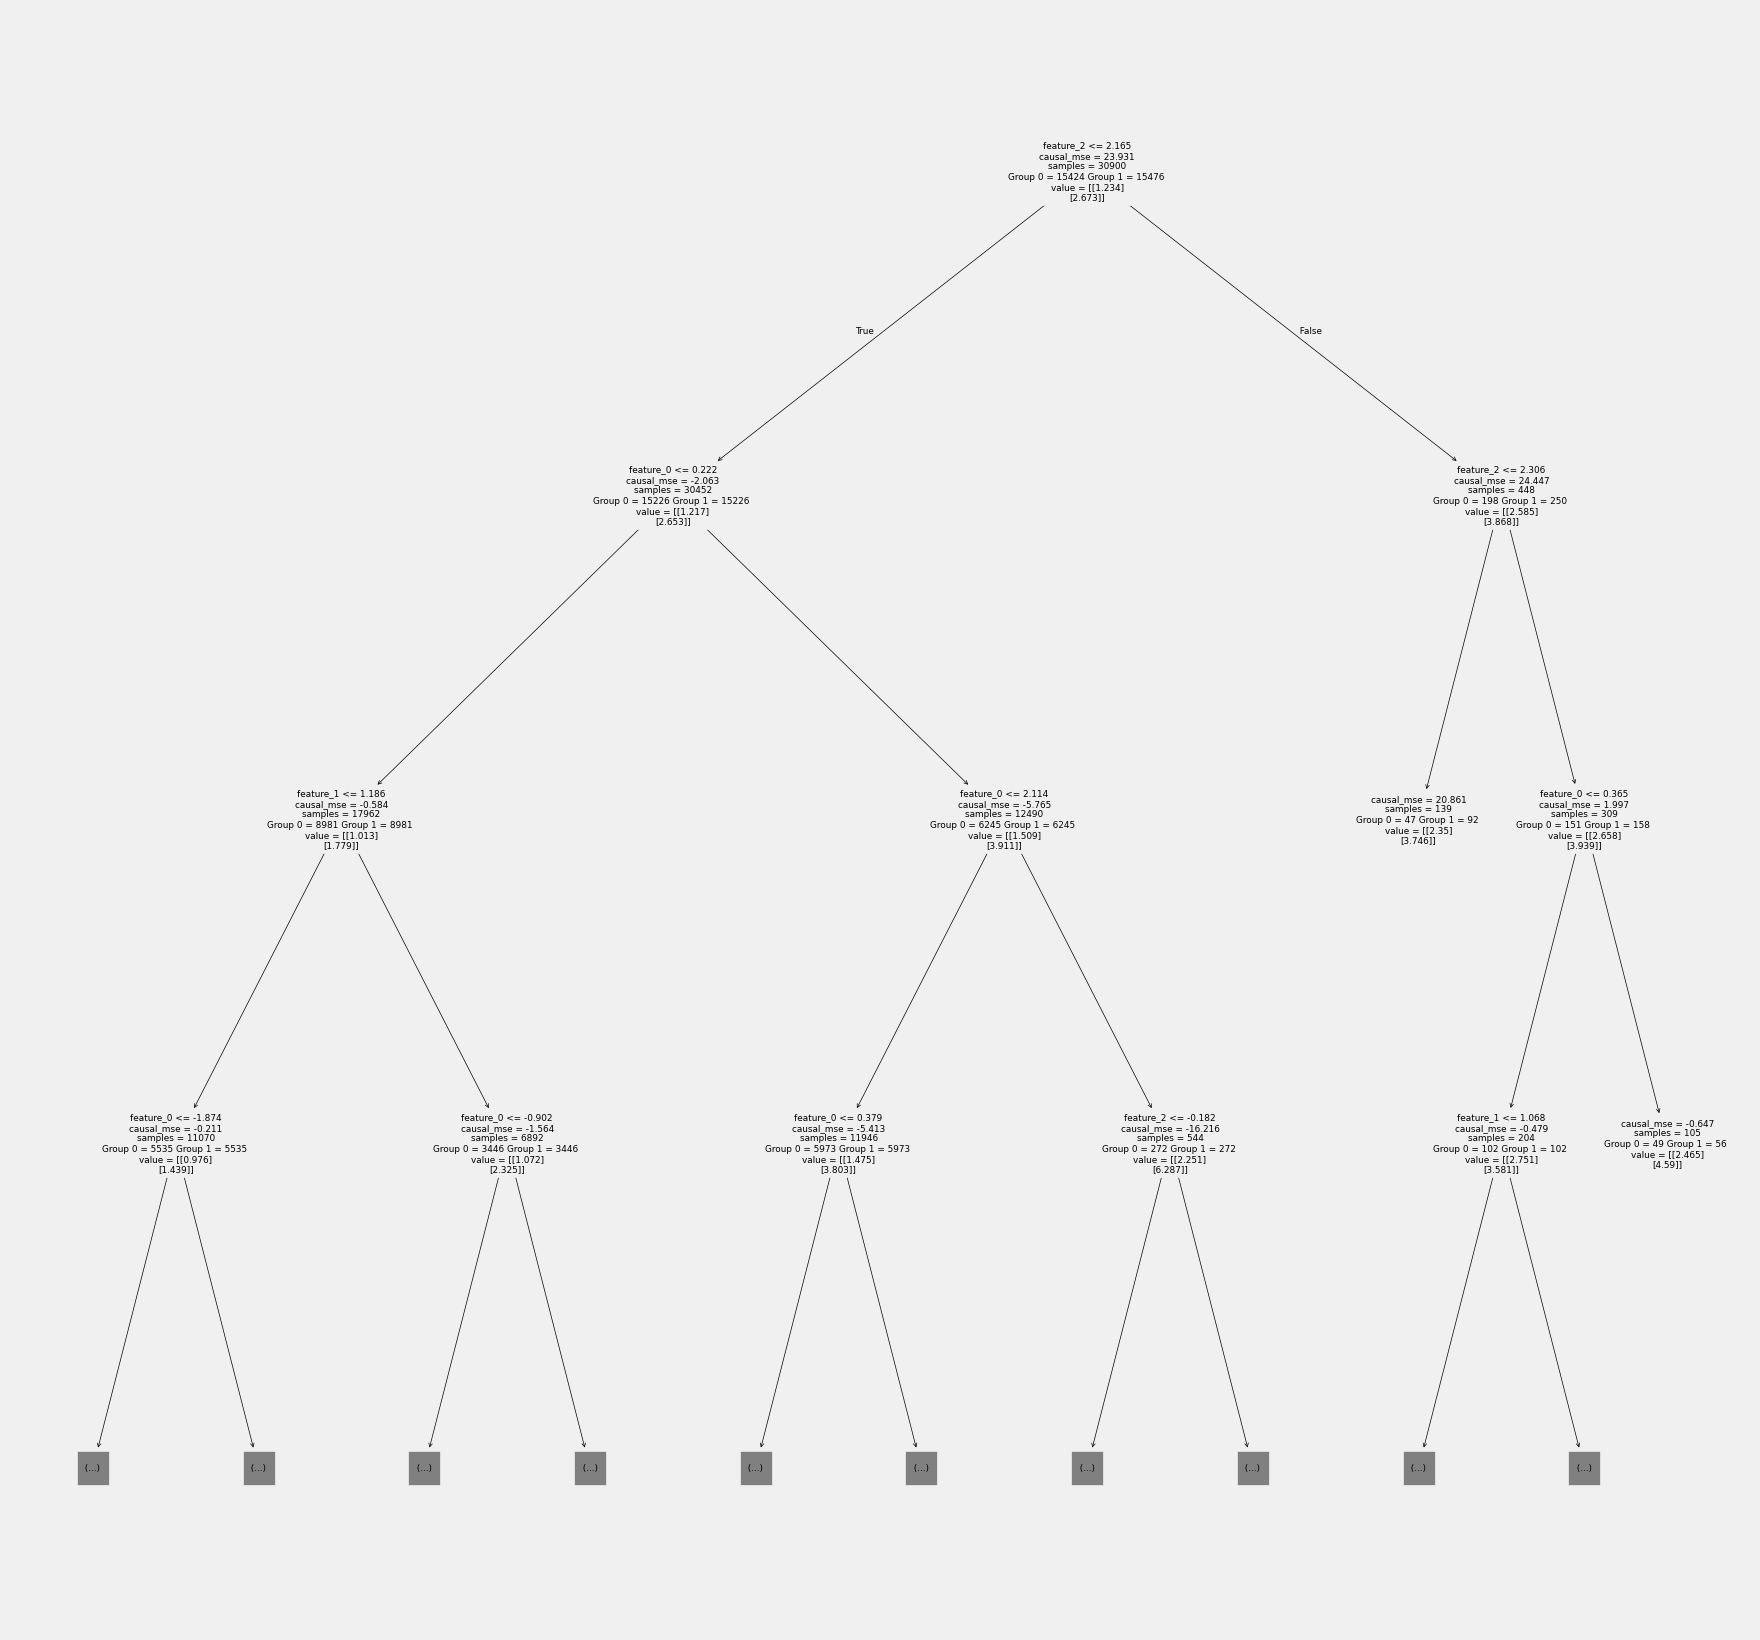

In [30]:
from causalml.inference.tree.plot import plot_causal_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))
plot_causal_tree(ctree, max_depth=3, feature_names=feature_names)

Root CATE: 1.439
  feature_2 <= 2.165,  CATE: 1.437, distance: 0.31
    feature_2 <= 2.165 AND feature_0 <= 0.222,  CATE: 0.766, distance: 0.25
      feature_2 <= 2.165 AND feature_0 <= 0.222 AND feature_1 <= 1.186,  CATE: 0.463, distance: 0.16
        feature_2 <= 2.165 AND feature_0 <= 0.222 AND feature_1 <= 1.186 AND feature_0 <= -1.874,  CATE: -1.063, distance: 0.02
        feature_2 <= 2.165 AND feature_0 <= 0.222 AND feature_1 <= 1.186 AND feature_0 > -1.874,  CATE: 0.548, distance: 0.15
      feature_2 <= 2.165 AND feature_0 <= 0.222 AND feature_1 > 1.186,  CATE: 1.253, distance: 0.22
        feature_2 <= 2.165 AND feature_0 <= 0.222 AND feature_1 > 1.186 AND feature_0 <= -0.902,  CATE: 0.451, distance: 0.07
        feature_2 <= 2.165 AND feature_0 <= 0.222 AND feature_1 > 1.186 AND feature_0 > -0.902,  CATE: 1.623, distance: 0.15
    feature_2 <= 2.165 AND feature_0 > 0.222,  CATE: 2.402, distance: 0.21
      feature_2 <= 2.165 AND feature_0 > 0.222 AND feature_0 <= 2.114,  CAT

In [19]:
%%time

# write a function that computes the jaccard distance between two dataframes
import pandas as pd

def jaccard_distance(df1, df2):
    df1 = df1.drop(columns=['outcome', 'treatment'])
    df2 = df2.drop(columns=['outcome', 'treatment'])
    intersection = df1.merge(df2).shape[0]
    union = df1.shape[0] + df2.shape[0] - intersection
    return intersection/union


q1 = sqldf("SELECT * FROM df WHERE feature_1 > 0.5")
q2 = sqldf("SELECT * FROM df WHERE feature_1 > 0.5 and feature_2>-1")

print(len(q1))
print(len(q2))

jaccard_distance(q1,q2)

31088
26089
CPU times: user 1.21 s, sys: 39.5 ms, total: 1.25 s
Wall time: 1.29 s


0.8391984045290788

In [20]:
%%time

from pandasql import sqldf

q1 = sqldf("SELECT * FROM df WHERE feature_1 > 0.5")
q2 = sqldf("SELECT * FROM df WHERE feature_1 > 0.5 and feature_2>-1")

CPU times: user 1.12 s, sys: 34.4 ms, total: 1.15 s
Wall time: 1.17 s


In [14]:
dff = pl.DataFrame(df)

In [21]:
%%time
ctx = pl.SQLContext(population=dff, eager=True)

df1 = ctx.execute("SELECT * FROM population WHERE feature_1 > 0.5")
df2 = ctx.execute("SELECT * FROM population WHERE feature_1 > 0.5 and feature_2>-1")

CPU times: user 2.42 ms, sys: 3.79 ms, total: 6.21 ms
Wall time: 1.52 ms


In [6]:
%%time
import polars as pl

df1 = pl.DataFrame(q1)
df2 = pl.DataFrame(q2)

CPU times: user 9.97 ms, sys: 14.6 ms, total: 24.6 ms
Wall time: 67.3 ms


In [9]:
%%time
q1.merge(q2)

CPU times: user 21.7 ms, sys: 3.75 ms, total: 25.5 ms
Wall time: 28.7 ms


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment
0,-0.517569,2.995388,1.388610,-0.598988,0.744653,0.751369,-0.679290,1.674606,-1.185082,0.671905,-1.542053,0
1,0.485993,0.603874,0.050125,-0.035225,-0.623864,-0.638655,0.212809,0.733468,-1.040185,-0.594961,-5.361601,0
2,-0.424930,1.187603,0.575121,0.579055,0.103554,0.501249,-0.193191,0.085597,0.334886,-0.310949,6.025246,1
3,-1.309609,1.739570,0.951239,0.377980,-1.793756,-0.097874,-1.842122,-0.708454,-0.365050,0.923255,3.577337,0
4,-2.358243,1.096856,-0.963127,-0.990062,-0.926226,0.218960,1.007991,-1.450857,-0.408567,0.675398,1.112942,1
...,...,...,...,...,...,...,...,...,...,...,...,...
26084,-0.351198,0.825919,0.918152,0.004317,-0.672849,-0.550994,-0.720778,1.002736,-0.671621,1.162375,-4.369236,0
26085,-1.295128,1.004860,-0.054372,2.048729,0.135596,-0.337681,-0.946490,-3.002473,-0.208454,-0.182296,3.594624,1
26086,0.802242,0.722751,-0.901934,-2.400430,1.631978,-0.654185,-0.627751,-1.110608,0.029764,0.214201,2.028293,0
26087,0.160780,0.772604,-0.342717,2.382094,0.768489,0.699924,1.370009,-2.672341,-1.666519,-0.039171,3.272246,1


In [8]:
%%time
df1.join(df2, how="inner", on=feature_names)


CPU times: user 7.14 ms, sys: 6.23 ms, total: 13.4 ms
Wall time: 2.8 ms


feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,outcome_right,treatment_right
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64
-0.517569,2.995388,1.38861,-0.598988,0.744653,0.751369,-0.67929,1.674606,-1.185082,0.671905,-1.542053,0,-1.542053,0
0.485993,0.603874,0.050125,-0.035225,-0.623864,-0.638655,0.212809,0.733468,-1.040185,-0.594961,-5.361601,0,-5.361601,0
-0.42493,1.187603,0.575121,0.579055,0.103554,0.501249,-0.193191,0.085597,0.334886,-0.310949,6.025246,1,6.025246,1
-1.309609,1.73957,0.951239,0.37798,-1.793756,-0.097874,-1.842122,-0.708454,-0.36505,0.923255,3.577337,0,3.577337,0
-2.358243,1.096856,-0.963127,-0.990062,-0.926226,0.21896,1.007991,-1.450857,-0.408567,0.675398,1.112942,1,1.112942,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.351198,0.825919,0.918152,0.004317,-0.672849,-0.550994,-0.720778,1.002736,-0.671621,1.162375,-4.369236,0,-4.369236,0
-1.295128,1.00486,-0.054372,2.048729,0.135596,-0.337681,-0.94649,-3.002473,-0.208454,-0.182296,3.594624,1,3.594624,1
0.802242,0.722751,-0.901934,-2.40043,1.631978,-0.654185,-0.627751,-1.110608,0.029764,0.214201,2.028293,0,2.028293,0


In [ ]:
# # print all nodes from sklearn tree_

# def print_tree(tree, node_id=0, parent_id=None, condition=False, depth=0, max_depth=4):
    
#     cate = round(tree.value[node_id][1][0] - tree.value[node_id][0][0],3)

#     if tree.children_left[node_id] == -1:  # indicates leaf
#         print(f"{depth * '  '} leaf CATE: {cate}")
#     else:
#         print(f"{depth * '  '}{tree.feature[node_id]} <= {round(tree.threshold[node_id],3)}, CATE: {cate}")

#         if depth < max_depth:
#             print_tree(tree, tree.children_left[node_id], node_id, True, depth + 1)
#             print_tree(tree, tree.children_right[node_id], node_id, False, depth + 1)


# print_tree(ctree.tree_)
